In [1]:
import pandas as pd 
import numpy as np 
import matplotlib as mlp 
import seaborn as sns 

In [2]:
df = pd.read_csv('churn.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [34]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

# data types & Details 
1. row number is unique value 
2. CustomerId is also unique value 
3. surname is also the unique value 
4. credit score is numerical continious value 
5. geograpy is catagorical nominal value 
6. gender is catagorical nominal value 
7. age is numerical continious value 
8. tenure (number of year that customer has been client of bank) is categorical ordinal value 
9. balance is numerical continious value 
10. NumOfProducts is catagorical ordinal value 
11. HasCrCard is catagorical nominal value 
12. is active is catagorical nominal value 
13. Estimated salary is numerical continious value 
14. Exited (whether or not the customer left the bank.) is catagorical nominal  value where 1 = yes and 0 = no 

In [27]:
df['Tenure'].value_counts()

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

In [5]:
# count occurrences of each Geography / IsActiveMember combination
df.groupby(['Geography', 'IsActiveMember']).size().reset_index(name='count')

,Geography,IsActiveMember,count
0,France,0,2423
1,France,1,2591
2,Germany,0,1261
3,Germany,1,1248
4,Spain,0,1165
5,Spain,1,1312


In [6]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [7]:
# rows and columns details 
rows, cols = df.shape
print(f"Rows: {rows}\nColumns: {cols}")

Rows: 10000
Columns: 14


In [10]:
# data info 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [8]:
# checking for missing values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [11]:
# quick statistics summary 
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


 # Univariable analysis 

<Axes: >

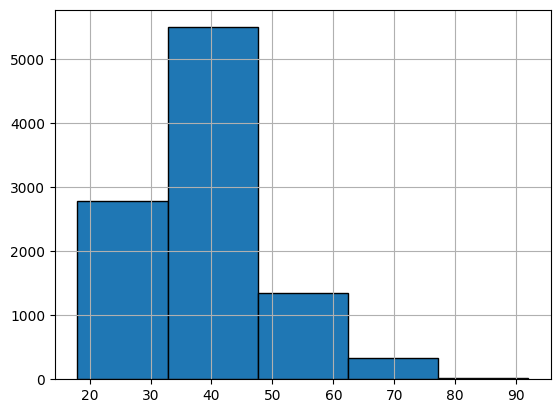

In [24]:
df['Age'].hist(bins=5, edgecolor='black')

<Axes: >

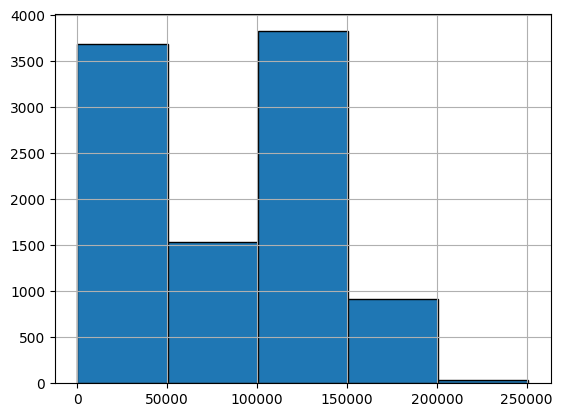

In [25]:
df['Balance'].hist(bins=5, edgecolor='black')

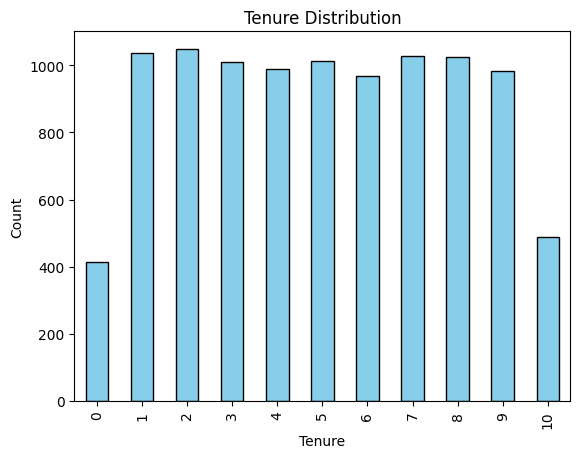

In [31]:
import matplotlib.pyplot as plt

df['Tenure'].value_counts().sort_index().plot.bar(
    color='skyblue', edgecolor='black'
)

plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.show()


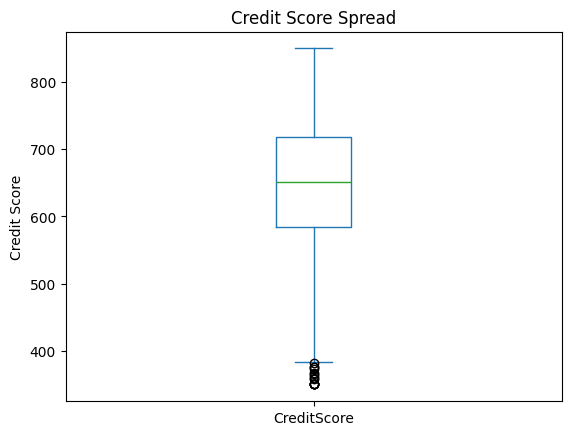

In [37]:
df['CreditScore'].plot(kind='box')
plt.title("Credit Score Spread")
plt.ylabel("Credit Score")
plt.show()
